# Reading a file into a data frame

In [1]:
# File identification
input_csv_file="your_file_path_here.csv"
input_xlsx_file="your_file_path_here.xlsx"
input_zipped_jsonl="euclidean_cluster0_articles.jsonl.gz"

### Use this space for installs -- add carefully

import sys
#!{sys.executable} -m pip install pandas numpy scipy scikit-learn hdbscan
#!{sys.executable} -m pip install --upgrade --force-reinstall \
    "pyarrow>=14,<17" \
    "pandas>=2.0,<3.0"

### Use this for a zipped json lines (jsonl) file

In [2]:
# Read zipped jsonl into data frame
from __future__ import annotations

import io
import json
import gzip
import zipfile
import re
from pathlib import Path
from typing import Iterable, Optional
import numpy as np

import pandas as pd
from pandas import json_normalize


# Fields that usually contain text worth modeling.
# Adjust this list to match your data.
TEXT_FIELDS = [
    "full_text",
    "title",
    "text",
    "body",
    "content",
    "summary",
    "description",
    "abstract",
    "headline",
]

# Fields that are useful as metadata but not usually part of the text vector.
ID_FIELDS = [
    "id",
    "doc_id",
    "uuid",
    "url",
    "source",
    "created_at",
    "published_at",
]


def _iter_json_records(path: str | Path, member_name: Optional[str] = None) -> Iterable[dict]:
    """
    Yield dict records from:
      - .jsonl
      - .jsonl.gz / .ndjson.gz
      - .zip containing a JSONL/NDJSON/JSON file
    """
    path = Path(path)
    suffixes = [s.lower() for s in path.suffixes]

    if suffixes and suffixes[-1] == ".gz":
        with gzip.open(path, "rt", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    yield json.loads(line)

    elif suffixes and suffixes[-1] == ".zip":
        with zipfile.ZipFile(path) as zf:
            names = zf.namelist()
            if not names:
                raise ValueError(f"No files found inside zip archive: {path}")

            if member_name is None:
                # Prefer likely JSONL members; otherwise fall back to the first member.
                preferred = [
                    n for n in names
                    if n.lower().endswith((".jsonl", ".ndjson", ".json"))
                ]
                member_name = preferred[0] if preferred else names[0]

            with zf.open(member_name) as raw:
                with io.TextIOWrapper(raw, encoding="utf-8") as f:
                    # Support both JSONL and regular JSON arrays stored in zip.
                    first_non_ws = None
                    for ch in iter(lambda: f.read(1), ""):
                        if ch.strip():
                            first_non_ws = ch
                            break
                    if first_non_ws is None:
                        return

                    f.seek(0)
                    if first_non_ws == "[":
                        # Regular JSON array inside the archive.
                        data = json.load(f)
                        if isinstance(data, list):
                            for rec in data:
                                if isinstance(rec, dict):
                                    yield rec
                        else:
                            raise ValueError("Expected a JSON array or JSONL records.")
                    else:
                        # JSON lines.
                        for line in f:
                            line = line.strip()
                            if line:
                                yield json.loads(line)

    else:
        # Plain .jsonl / .ndjson / .jsonl-like text file
        with open(path, "rt", encoding="utf-8") as f:
            first_non_ws = None
            for ch in iter(lambda: f.read(1), ""):
                if ch.strip():
                    first_non_ws = ch
                    break
            if first_non_ws is None:
                return

            f.seek(0)
            if first_non_ws == "[":
                data = json.load(f)
                if isinstance(data, list):
                    for rec in data:
                        if isinstance(rec, dict):
                            yield rec
                else:
                    raise ValueError("Expected a JSON array or JSONL records.")
            else:
                for line in f:
                    line = line.strip()
                    if line:
                        yield json.loads(line)


def _clean_piece(x) -> str:
    if x is None:
        return ""

    # Handle numpy arrays / lists FIRST
    if isinstance(x, (list, tuple, np.ndarray)):
        return " ".join(
            str(v).strip()
            for v in x
            if v is not None and not (isinstance(v, float) and pd.isna(v))
        )

    # Now safe to check scalar NaN
    if isinstance(x, (float, int)) and pd.isna(x):
        return ""

    if isinstance(x, dict):
        return ""

    return str(x).strip()


def load_text_analysis_frame(
    path: str | Path,
    member_name: Optional[str] = None,
    text_fields: list[str] = TEXT_FIELDS,
    id_fields: list[str] = ID_FIELDS,
) -> pd.DataFrame:
    """
    Read compressed JSONL/JSON into a modeling-ready DataFrame.

    Output:
      - one row per document/record
      - nested dicts flattened
      - analysis_text column built from useful text fields
      - metadata kept in other columns for joins / inspection
    """
    records = list(_iter_json_records(path, member_name=member_name))
    if not records:
        raise ValueError("No JSON records were found.")

    # Flatten nested dict fields into columns like author_name, doc_meta_lang, etc.
    df = json_normalize(records, sep="_")

    # Build the text column from available text fields.
    present_text_cols = [c for c in text_fields if c in df.columns]
    if not present_text_cols:
        raise ValueError(
            f"None of the expected text fields were found. Available columns: {list(df.columns)[:50]}"
        )

    def combine_row(row):
        pieces = [_clean_piece(row[c]) for c in present_text_cols]
        pieces = [p for p in pieces if p]
        return " ".join(pieces)

    df["analysis_text"] = df[present_text_cols].apply(combine_row, axis=1)

    # Clean up text for modeling.
    df["analysis_text"] = (
        df["analysis_text"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Keep only rows with usable text.
    df = df[df["analysis_text"].ne("") & df["analysis_text"].ne("nan")].copy()

    # Make IDs consistent if present.
    for col in id_fields:
        if col in df.columns:
            df[col] = df[col].astype("string")

    # Optional: create a stable document id if none exists.
    if not any(c in df.columns for c in ("doc_id", "id", "uuid")):
        df.insert(0, "doc_id", [f"doc_{i}" for i in range(len(df))])

    # Drop exact duplicate texts if appropriate for clustering.
    df = df.drop_duplicates(subset=["analysis_text"]).reset_index(drop=True)

    return df


# Example usage
df = load_text_analysis_frame(input_zipped_jsonl)   # or .zip
print(df.columns)
print(df[["analysis_text"]].head())

Index(['doc_id', 'iid', 'full_text', 'references', 'analysis_text'], dtype='str')
                                       analysis_text
0  BASEL INSTITUTE ON GOVERNANCE 5 23 BASEL INSTI...
1  11 PEW RESEARCH CENTER 1. South Africans worri...
2  Chapter 8: The Criminology of Corruption Wim H...
3  PREFACE In 2015 the G20 Anti-Corruption Open T...
4  IZA DP No. 8521 Emigration, Remittances and Co...


In [3]:
print(df.head())

  doc_id                                   iid  \
0  doc_0  02a7e245-95f7-3b7a-8747-702144fe94b0   
1  doc_1  0282bde2-ec4b-30e7-92b5-1b5d9c2540f4   
2  doc_2  07639aea-9cc4-3ad2-94c4-67c0ddc27c7a   
3  doc_3  05c3c4b4-52e3-366a-b636-5ec1e351b05a   
4  doc_4  0af96324-3319-38e8-b7c6-3164b59ef986   

                                           full_text references  \
0  [BASEL INSTITUTE ON GOVERNANCE 5 23, BASEL INS...         []   
1  [11 PEW RESEARCH CENTER 1. South Africans worr...         []   
2  [Chapter 8: The Criminology of Corruption Wim ...         []   
3  [PREFACE In 2015 the G20 Anti-Corruption Open ...         []   
4  [IZA DP No. 8521 Emigration, Remittances and C...         []   

                                       analysis_text  
0  BASEL INSTITUTE ON GOVERNANCE 5 23 BASEL INSTI...  
1  11 PEW RESEARCH CENTER 1. South Africans worri...  
2  Chapter 8: The Criminology of Corruption Wim H...  
3  PREFACE In 2015 the G20 Anti-Corruption Open T...  
4  IZA DP No. 8521 Em

# Export
df.to_csv(
    "Islands_output32526.csv.gz",
    index=False,
    encoding="utf-8",
    compression="gzip",
)

# Clean export
import csv
import json
import pandas as pd

# Choose only the columns you actually want to carry forward
keep_cols = [c for c in ["doc_id", "iid", "analysis_text", "cluster"] if c in df.columns]
out = df[keep_cols].copy()

# Make sure text is plain scalar text, not lists/dicts
def to_text(x):
    if x is None or pd.isna(x):
        return ""
    if isinstance(x, (list, tuple, set)):
        return " ".join(str(v).strip() for v in x if v is not None and not pd.isna(v))
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    return str(x)

for col in out.columns:
    out[col] = out[col].map(to_text)

# Remove embedded newlines that make CSVs look broken in Excel
if "analysis_text" in out.columns:
    out["analysis_text"] = (
        out["analysis_text"]
        .str.replace(r"[\r\n]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# Write a robust CSV
out.to_csv(
    "Islands_df_32526.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_ALL,
    escapechar="\\",
)

In [4]:
# Export modelling-ready df
import pandas as pd
import numpy as np
import json
import csv
from pathlib import Path

# Keep only the columns you actually need
keep_cols = [c for c in ["doc_id", "iid", "analysis_text"] if c in df.columns]
out = df[keep_cols].copy()

def scalar_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    if isinstance(x, (list, tuple, set)):
        parts = []
        for v in x:
            if v is None:
                continue
            if isinstance(v, float) and pd.isna(v):
                continue
            parts.append(str(v).strip())
        return " ".join(p for p in parts if p)
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    return str(x).strip()

for col in out.columns:
    out[col] = out[col].map(scalar_text)

# Clean the text column hard
if "analysis_text" in out.columns:
    out["analysis_text"] = (
        out["analysis_text"]
        .str.replace(r"[\r\n]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# Drop empty text rows
out = out[out["analysis_text"].ne("")].reset_index(drop=True)

# Export CSV in a way Excel is less likely to mangle
out.to_csv(
    "Islands_model_ready_text32526B.csv",
    index=False,
    encoding="utf-8-sig",
    quoting=csv.QUOTE_ALL,
)

# Also export Parquet for Python use
out.to_parquet("model_ready_text.parquet", index=False)

In [5]:
# Visual checks for irregularities
# Iteration 1
df[["doc_id", "analysis_text"]].sample(50, random_state=42)
df.loc[df["analysis_text"].str.len().nlargest(50).index, ["doc_id", "analysis_text"]]

,doc_id,analysis_text
102,doc_102,CONTENTS Preface _____________________________...
407,doc_407,ACKNOWLEDGEMENtS I would like to extend my hea...
73,doc_73,THREE. OIL AND THE “ARMY ARRANGEMENT” Corrupti...
432,doc_432,6 Controlling corruption by heads of governmen...
251,doc_251,III. REPORTS ON NON-OECD CONVENTION COUNTRIES ...
409,doc_409,Annex 2: Affinity Group Members Bruce Abrams K...
72,doc_72,Appendix STATISTICAL ANALYSIS This appendix pr...
6,doc_6,Contributors Manuhuia Barcham is Managing Dire...
28,doc_28,ABOUT THE AUTHOR SARAH CHAYES is a senior fell...
98,doc_98,7. Tunisia: Great Expectations JANA WARKOTSCH1...


# Cleaning

In [6]:
# Flag suspect rows
import re
import pandas as pd

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = text.replace("â€™", "'").replace("â€œ", '"').replace("â€", '"')
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.copy()
df["analysis_text"] = df["analysis_text"].fillna("").map(normalize_text)

# Quality flags, not hard drops
df["char_len"] = df["analysis_text"].str.len()
df["word_count"] = df["analysis_text"].str.split().str.len()
df["has_table_of_contents"] = df["analysis_text"].str.contains("table of contents", case=False, na=False)
df["has_octalish_garble"] = df["analysis_text"].str.contains(r"[A-Z]{4,}[^a-zA-Z]+[A-Z]{4,}", na=False)
df["mostly_caps"] = df["analysis_text"].str.split().apply(
    lambda ws: (sum(w.isupper() for w in ws) / len(ws)) if len(ws) else 0
)

# Only remove the most obvious non-doc rows
keep = (
    df["analysis_text"].ne("") &
    df["char_len"].ge(20) &
    ~df["has_table_of_contents"]
)

df_clean = df[keep].copy()

In [7]:
# Inspect distributions
print(df["char_len"].describe())
print(df["word_count"].describe())
print("table of contents:", df["has_table_of_contents"].sum())
print("char_len < 50:", (df["char_len"] < 50).sum())
print("mostly_caps > 0.8:", (df["mostly_caps"] > 0.8).sum())

count       435.000000
mean      64073.296552
std      104804.589613
min          25.000000
25%       15183.500000
50%       39454.000000
75%       70000.000000
max      870833.000000
Name: char_len, dtype: float64
count       435.000000
mean       9584.004598
std       15705.301965
min           4.000000
25%        2287.500000
50%        5943.000000
75%       10357.500000
max      134124.000000
Name: word_count, dtype: float64
table of contents: 33
char_len < 50: 2
mostly_caps > 0.8: 0


# Finding suspicious articles

In [8]:
# View edge cases
# shortest texts
df.loc[df["char_len"].nsmallest(50).index, ["doc_id", "analysis_text", "char_len", "word_count", "mostly_caps"]]

,doc_id,analysis_text,char_len,word_count,mostly_caps
324,doc_324,for corruption and health,25,4,0.000000
52,doc_52,( ( Body hierarchy Responsibilities,35,5,0.000000
158,doc_158,Resource Governance Index Resource Governance ...,51,6,0.000000
53,doc_53,Institute for Advanced Development Studies Dev...,491,68,0.014706
55,doc_55,for Defence and Security Studies Workshop Repo...,882,130,0.053846
163,doc_163,PUTTING CORRUPTION ON THE AGENDA How corrupt i...,914,143,0.069930
302,doc_302,Ten Red Flags for Corruption Risk in Transitio...,1358,236,0.038136
189,doc_189,I 1 2 corruption. 3 This social services and e...,1394,217,0.032258
0,doc_0,BASEL INSTITUTE ON GOVERNANCE 5 23 BASEL INSTI...,1440,233,0.652361
284,doc_284,I policy documents. Policy Context • Serious a...,1717,282,0.021277


In [9]:
# View edge cases
# Mostly caps
df.loc[df["mostly_caps"].nlargest(10).index, ["doc_id", "analysis_text", "char_len", "word_count", "mostly_caps"]]

,doc_id,analysis_text,char_len,word_count,mostly_caps
0,doc_0,BASEL INSTITUTE ON GOVERNANCE 5 23 BASEL INSTI...,1440,233,0.652361
136,doc_136,BASEL INSTITUTE ON GOVERNANCE 1 - - - - - - 4 ...,2246,289,0.470588
179,doc_179,TRANSPARENCY INTERNATIONAL WHAT DO CITIZENS TH...,10737,1703,0.172637
211,doc_211,WOMEN & CORRUPTION IN LATIN Sextortion What do...,5955,919,0.153428
321,doc_321,TRANSPARENCY INTERNATIONAL / AFROBAROMETER WHA...,99397,16605,0.138934
381,doc_381,/D WUDQVLWLRQ EORTXpH FRUUXSWLRQ HW UpJLRQDOLV...,122462,17810,0.138012
386,doc_386,TRANSPARENCY INTERNATIONAL HOW ARE CITIZENS AF...,5245,866,0.137413
402,doc_402,TRANSPARENCY INTERNATIONAL GLOBAL CORRUPTION B...,21629,3476,0.123130
332,doc_332,BASEL INSTITUTE ON GOVERNANCE 2. 3 NATIONAL EC...,23272,3850,0.118701
242,doc_242,Research - Case Study 3 May 2023 Exposing the ...,5495,812,0.112069


# Decision: Drop documents outside IQR +/- .5 (20-80 percentiles) --> Targets our unit of analysis: journal articles

In [10]:
# Include only .25-.75 percentile range ###=== lab note: tried .20-.80 but it left in articles down to 4 words long -- upper skew issue===###
q1 = df["char_len"].quantile(0.25)
q3 = df["char_len"].quantile(0.75)
iqr = q3 - q1

lower = q1   # smaller buffer
upper = q3

df_iqr = df[(df["char_len"] >= lower) & (df["char_len"] <= upper)].copy()

In [11]:
# Check new distribution
print(df_iqr["char_len"].describe())
print(df_iqr["word_count"].describe())
print("table of contents:", df_iqr["has_table_of_contents"].sum())
print("char_len < 50:", (df_iqr["char_len"] < 50).sum())
print("mostly_caps > 0.8:", (df_iqr["mostly_caps"] > 0.8).sum())

count      217.000000
mean     39713.506912
std      15589.419400
min      15433.000000
25%      25255.000000
50%      39454.000000
75%      52033.000000
max      69995.000000
Name: char_len, dtype: float64
count      217.000000
mean      5982.640553
std       2325.277070
min       2267.000000
25%       3865.000000
50%       5943.000000
75%       7904.000000
max      10912.000000
Name: word_count, dtype: float64
table of contents: 10
char_len < 50: 0
mostly_caps > 0.8: 0


In [12]:
# Check for duplicates
df_iqr["analysis_text"].value_counts().head(10)

analysis_text
11 PEW RESEARCH CENTER 1. South Africans worried about crime and corruption, prioritize education More than a year after the United Nations adopted 17 global objectives for development, known as the Sustainable Development Goals, South Africa is facing increasingly serious hurdles to achieving some of those key targets. The Organization for Economic Cooperation and Development (OECD) has projected that the country’s economy will weaken even further this year from its already-slowed 2015 growth, due in part to political uncertainty and electricity shortages. President Jacob Zuma survived an April 5 impeachment vote stemming from accusations of corruption, and his party, the African National Congress (ANC), suffered significant losses in local elections in August. Almost three-quarters of South Africans are dissatisfied with the way things are going in their country. Overwhelming majorities see many issues, including crime, unemployment and government corruption, as serious

### No duplicates detected

In [13]:
# Quick token check --- sanity
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words="english", max_features=30)
X = vec.fit_transform(df_iqr["analysis_text"])
terms = vec.get_feature_names_out()
counts = X.sum(axis=0).A1

sorted(zip(terms, counts), key=lambda x: x[1], reverse=True)

[('corruption', np.int64(18292)),
 ('public', np.int64(4149)),
 ('government', np.int64(3546)),
 ('anti', np.int64(3457)),
 ('international', np.int64(3111)),
 ('political', np.int64(2928)),
 ('transparency', np.int64(2825)),
 ('police', np.int64(2550)),
 ('state', np.int64(2347)),
 ('countries', np.int64(2253)),
 ('et', np.int64(1952)),
 ('law', np.int64(1847)),
 ('country', np.int64(1805)),
 ('people', np.int64(1800)),
 ('data', np.int64(1638)),
 ('corrupt', np.int64(1636)),
 ('sector', np.int64(1590)),
 ('economic', np.int64(1558)),
 ('la', np.int64(1505)),
 ('information', np.int64(1456)),
 ('new', np.int64(1449)),
 ('report', np.int64(1422)),
 ('www', np.int64(1407)),
 ('national', np.int64(1396)),
 ('institutions', np.int64(1344)),
 ('level', np.int64(1302)),
 ('org', np.int64(1266)),
 ('development', np.int64(1251)),
 ('world', np.int64(1248)),
 ('social', np.int64(1247))]

### There's a bit of noise (www, et, and maybe org)... but acceptable for BERT

# Embed

In [14]:
# Embed with sentence-transformers
from sentence_transformers import SentenceTransformer

# Convert to list vs series
df_iqr = df_iqr.reset_index(drop=True)
texts = df_iqr["analysis_text"].fillna("").astype(str).tolist()

model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(df_iqr["analysis_text"], show_progress_bar=True)

C:\Users\oliver20\CORRUPTJEDI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 6506.35it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [00:51<00:00,  7.33s/it]


# UMAP

In [16]:
# UMAP
import umap

umap_model = umap.UMAP(
    n_neighbors=15, # These look reasonable
    n_components=5, # These look reasonable
    min_dist=0.0,
    metric="cosine"    
)

X_umap = umap_model.fit_transform(embeddings)

In [103]:
# HDBSCAN
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=6,
    min_samples=5,
    metric="euclidean"
)

df_iqr["cluster"] = clusterer.fit_predict(X_umap)

In [104]:
# Cluster sanity check
df_iqr["cluster"].value_counts()

cluster
 6    47
-1    45
 1    33
 8    24
 4    19
 5    13
 2    12
 0     9
 7     8
 3     7
Name: count, dtype: int64

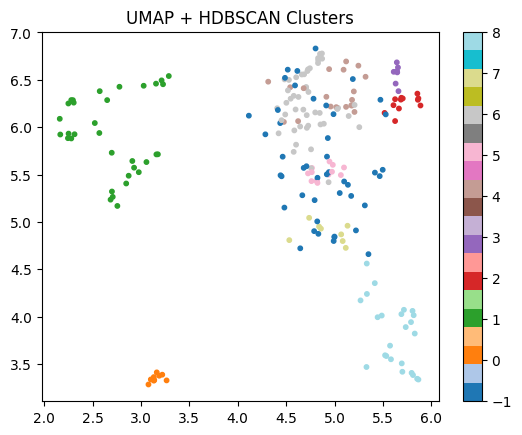

In [105]:
# UMAP scatter plot
import matplotlib.pyplot as plt

plt.scatter(X_umap[:, 0], X_umap[:, 1], c=df_iqr["cluster"], cmap="tab20", s=10)
plt.colorbar()
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

C:\Users\oliver20\CORRUPTJEDI\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


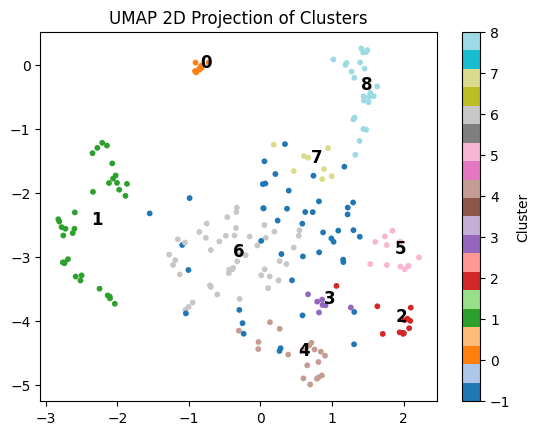

In [106]:
# Numbered clusters
import umap

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,   
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

X_2d = umap_2d.fit_transform(embeddings)

for cluster in df_iqr["cluster"].unique():
    if cluster == -1:
        continue
    
    mask = df_iqr["cluster"] == cluster
    x_mean = X_2d[mask, 0].mean()
    y_mean = X_2d[mask, 1].mean()
    
    plt.text(x_mean, y_mean, str(cluster), fontsize=12, weight="bold")

import matplotlib.pyplot as plt

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df_iqr["cluster"], cmap="tab20", s=10)
plt.colorbar(label="Cluster")
plt.title("UMAP 2D Projection of Clusters")
plt.show()

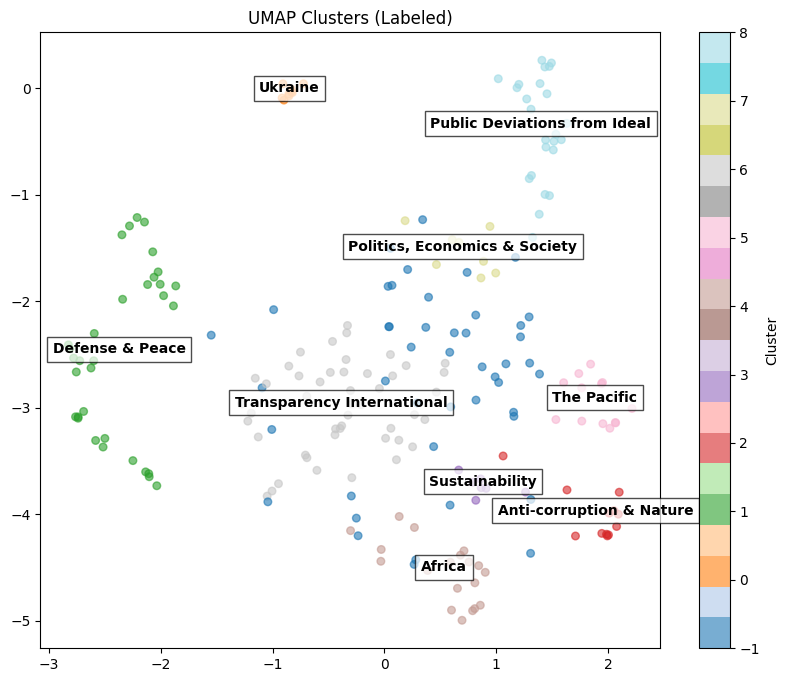

In [113]:
cluster_labels = {
    0: "Ukraine",
    1: "Defense & Peace",
    2: "Anti-corruption & Nature",
    3: "Sustainability",
    4: "Africa",
    5: "The Pacific",
    6: "Transparency International",
    7: "Politics, Economics & Society",
    8: "Public Deviations from Ideal",
}

# Labelled clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot points FIRST
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df_iqr["cluster"],
    cmap="tab20",
    s=30,              # bigger points
    alpha=0.6          # slightly transparent
)

# Label cluster centers (not every point)
for cluster in df_iqr["cluster"].unique():
    if cluster == -1:
        continue
    
    mask = df_iqr["cluster"] == cluster
    
    # Skip tiny clusters (prevents noise labels)
    if mask.sum() < 5:
        continue
    
    x_mean = X_2d[mask, 0].mean()
    y_mean = X_2d[mask, 1].mean()
    
    label = cluster_labels.get(cluster, str(cluster))
    
    plt.text(
        x_mean,
        y_mean,
        label,
        fontsize=10,
        weight="bold",
        ha="center",
        bbox=dict(facecolor="white", alpha=0.7)
    )

plt.colorbar(scatter, label="Cluster")
plt.title("UMAP Clusters (Labeled)")
plt.show()

# Outputs
Click to view

# Results:
min cluster 10
min samples 5

175
33
noise = 9
|===========================|
min cluster 9
min samples 5

175
33
9
noise = 0
|===========================|
min cluster 8 through 7
min samples 5

175
33
9
noise = 0
---> no change 

|===========================|
min cluster 6
min samples 5

0 9
1 33
2 12
3 7
4 19
5 13
6 47
7 8
8 24
noise = 45

Lowering the cluster membership reveals islands of high-density med-low noise 20.7373%

# Three cluster

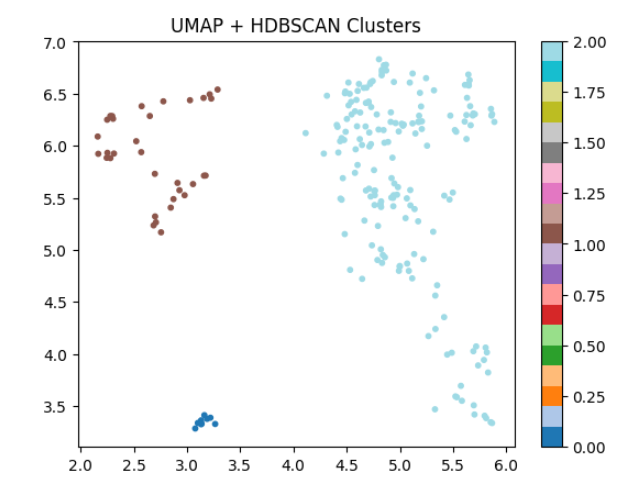

min cluster = 7, min samples = 5, euclidean, eom

# Nine cluster (note: cluster size of 7 --> 3, cluster size of 6 --> 9)
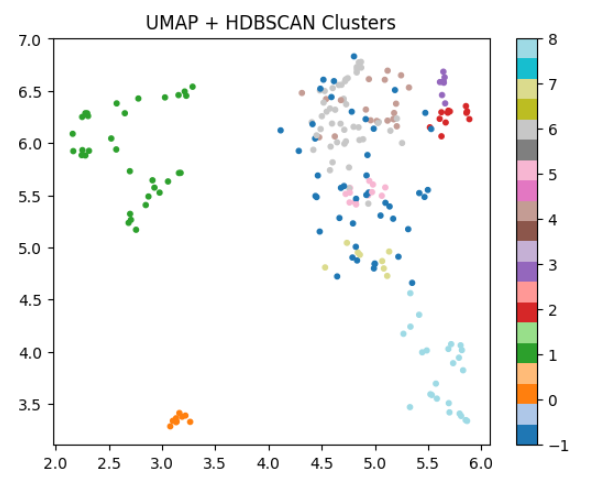

# Manhattan, cluster size = 6 merges a visually distinct region
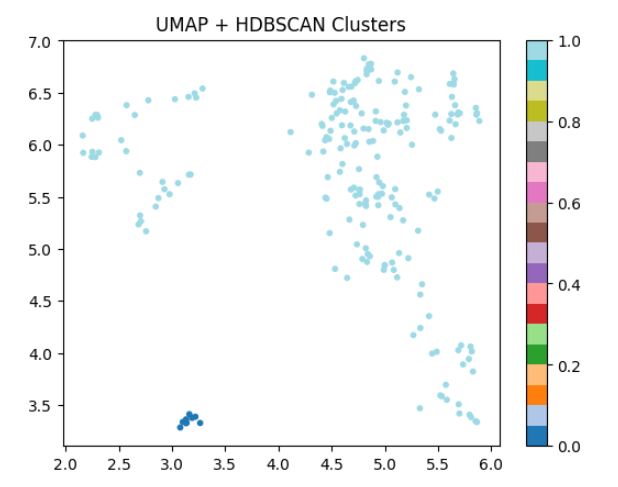

# Three cluster labelled
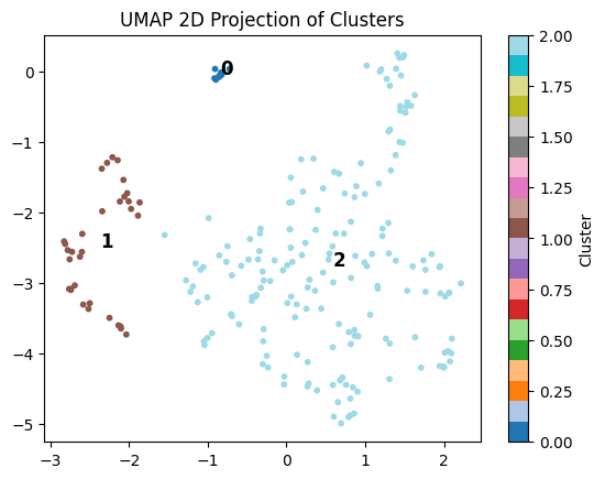

# Min cluster = 6, min samples = 5, euclidean, eom
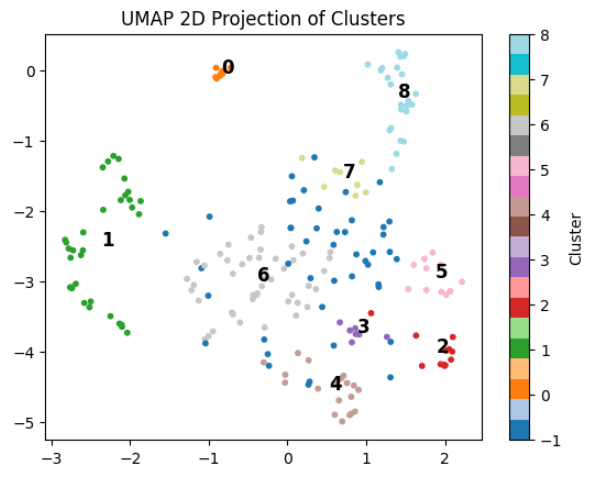

NB: Dark blue is noise

# Labeled k=9 
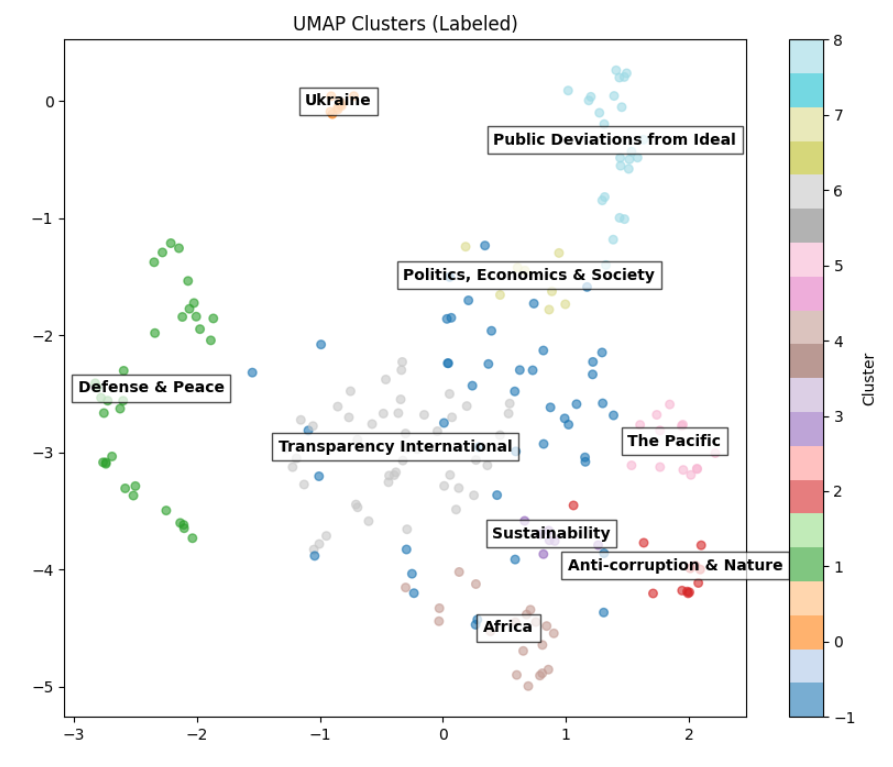

# Naming clusters

In [107]:
# Define function to get top representative documents by centroid
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances

def representative_docs_by_cluster(
    df,
    embeddings,
    cluster_col="cluster",
    text_col="analysis_text",
    id_col="doc_id",
    n_per_cluster=3,
    exclude_noise=True,
):
    """
    Return the n most representative documents per cluster.
    Representative = closest to the cluster centroid in embedding space.
    """
    df = df.reset_index(drop=True).copy()

    if len(df) != len(embeddings):
        raise ValueError("df and embeddings must have the same number of rows.")

    rows = []

    clusters = sorted(df[cluster_col].dropna().unique())
    for cl in clusters:
        if exclude_noise and cl == -1:
            continue

        idx = df.index[df[cluster_col] == cl].to_numpy()
        if len(idx) == 0:
            continue

        cluster_emb = embeddings[idx]
        centroid = cluster_emb.mean(axis=0, keepdims=True)

        # cosine distance: smaller = more representative
        dists = cosine_distances(cluster_emb, centroid).ravel()
        top_local = np.argsort(dists)[:n_per_cluster]
        top_idx = idx[top_local]

        for rank, i in enumerate(top_idx, start=1):
            rows.append({
                "cluster": cl,
                "rank": rank,
                "doc_index": int(i),
                "doc_id": df.at[i, id_col] if id_col in df.columns else i,
                "distance_to_centroid": float(dists[top_local[rank - 1]]),
                "text": df.at[i, text_col],
            })

    return pd.DataFrame(rows).sort_values(["cluster", "rank"]).reset_index(drop=True)

In [108]:
# Call function with desired specs
rep = representative_docs_by_cluster(
    df_iqr,
    embeddings,
    cluster_col="cluster",
    text_col="analysis_text",
    id_col="doc_id",
    n_per_cluster=5,
    exclude_noise=True,
)

rep

,cluster,rank,doc_index,doc_id,distance_to_centroid,text
0,0,1,64,doc_145,0.064117,"Corruption, Democracy, and Investment in Ukrai..."
1,0,2,107,doc_222,0.064788,"Corruption in Ukraine: Essence, Scale, and Inf..."
2,0,3,4,doc_12,0.068733,CHAPTER 1 Fighting Corruption to Secure Ukrain...
3,0,4,101,doc_210,0.078782,Journal of Strategic Security Volume 17 Number...
4,0,5,114,doc_237,0.084276,"24 CORRUPTION, DEMOCRACY, AND INVESTMENT IN UK..."
5,1,1,161,doc_326,0.138301,Journal of Strategic Security Volume 13 Number...
6,1,2,197,doc_394,0.163622,UNITeD STATeS INSTITUTe of PeACe www.usip.org ...
7,1,3,75,doc_167,0.168119,Enabling Factors and Effects of Corruption in ...
8,1,4,168,doc_342,0.168162,FRAGILITY POLICY BRIEF STUDY GROUP NO. 1 • SEP...
9,1,5,65,doc_146,0.170471,Building Integrity and Reducing Corruption Ris...


In [109]:
# Export to csv
rep.to_csv("corruption_cluster_representatives_9cluster_B32526.csv", index=False)